In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay   # New!

In [ ]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load and preview data
fish_url ="https://docs.google.com/spreadsheets/d/e/2PACX-1vQzdl1eZJPaosIIIBYwaru6J9eGwHz8RGz_uQhVD8S58dOoluhqVZ3xUIzRKdm713V-pRnd5awH2Fyv/pub?output=csv"
dff = pd.read_csv(fish_url)
dff.info()
dff.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [ ]:
# Check for null values
dff.isna().sum().sum()

np.int64(0)

In [ ]:
# Separate X,y and train test split
target = 'Species'
X = dff.drop(columns=target)
y = dff[target]
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)
# Checking the class balance
y_train.value_counts(normalize=True).sort_index()

,proportion
Species,
Bream,0.201681
Parkki,0.075630
Perch,0.369748
Pike,0.109244
Roach,0.142857
Smelt,0.075630
Whitefish,0.025210


In [ ]:
# Create the model pipeline with a scaler
scaler = StandardScaler()
clf_pipe = make_pipeline(scaler,
                         DecisionTreeClassifier(random_state=42))

In [ ]:
# Fit the model and get predictions
clf_pipe.fit(X_train, y_train)
y_pred_test = clf_pipe.predict(X_test)

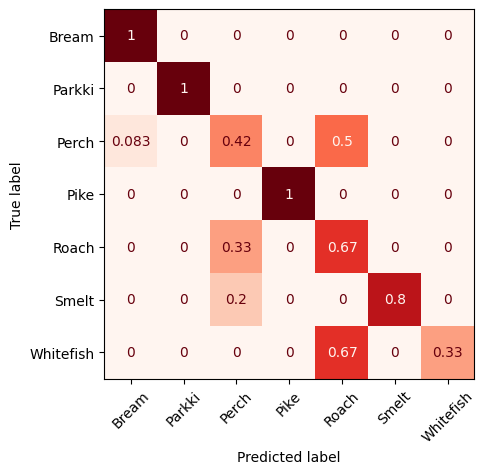

In [ ]:
# Plot the confusion matrix from the predictions
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test,normalize='true',
                                        xticks_rotation=45,colorbar=False,
                                        cmap='Reds')

📌 Normalized Confusion Matrix + Classification Report

النموذج كان ممتاز جدًا في بعض الكلاسات:

✔ Bream = 100% صحيح

✔ Parkki = 100% صحيح

✔ Pike = 100% صحيح

لكن أداؤه كان ضعيف في كلاس واحد مهم:

❌ Perch

42% فقط تم تصنيفهم صح

50% تم تصنيفهم خطأ كـ Roach

نسبة قليلة جدًا تم تصنيفها كـ Bream

In [ ]:
# Print the classification report.
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

       Bream       0.92      1.00      0.96        11
      Parkki       1.00      1.00      1.00         2
       Perch       0.71      0.42      0.53        12
        Pike       1.00      1.00      1.00         4
       Roach       0.20      0.67      0.31         3
       Smelt       1.00      0.80      0.89         5
   Whitefish       1.00      0.33      0.50         3

    accuracy                           0.72        40
   macro avg       0.83      0.75      0.74        40
weighted avg       0.83      0.72      0.74        40

